In [199]:
cluster_number = 0 
seed_name = 'ANH82019.1'


#'''{'Cluster_0': ['ANH82019.1'], 'Cluster_1': ['Burkholderia_xenovorans_YP_557005'], 'Cluster_2': ['Neosartorya_fischeri_XP_001266691'], 'Cluster_3': ['YP_432621.1_SAM-dependent_methyltransferase'], 'Cluster_4': ['Algoriphagus_sp._ZP_01720187'], 'Cluster_5': ['ZP_00987534.1_COG0500_SAM-dependent_methyltransferases'], 'Cluster_6': ['Anaeromyxobacter_dehalogenans_YP_466408'], 'Cluster_7': ['Polaribacter_irgensii_ZP_01117536'], 'Cluster_8': ['3LCC_A'], 'Cluster_9': ['YP_522685.1_thiopurine_S-methyltransferase']}'''

# Imports

In [200]:
# import packages
import os, sys, glob
import numpy as np
import pandas as pd
import multiprocessing as mp
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import argparse

from functools import partial
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sys.path.append('../')

In [201]:
# Check if the variables exist, otherwise set default values
if 'cluster_number' not in globals():
    cluster_number = None # Default value if not set externally

if 'seed_name' not in globals():
    seed_name = None  # Default value if not set externally

#cluster_number = 0 0 0
#seed_name = "ANH82019.1" "ANH82019.1" 'ANH82019.1'
print(f"Running notebook with Cluster: {cluster_number}, Seed Name: {seed_name}")

Running notebook with Cluster: 0, Seed Name: ANH82019.1


# Preprocessing

In [202]:
# load data such that each row is a sample with one column for name and one for sequence
# add sequence 'names as a ft
def load_data(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        seqs = []
        names = []
        for i in range(0, len(lines)):
            # split line by tab
            line = lines[i].split('\t')
            names.append(line[0][1:].strip())
            seqs.append(line[1].strip())
    return pd.DataFrame({'name': names,
                         'sequence': seqs})
# Big clustering
#seqs = load_data('../data/Final_Sequences_PlusRefSeq20.clustalo.Output.oneline.Residue_Columns_With_2Nbrs.txt')
#Sub-clustering
cluster_data_path = f"/Users/3et/ilenne/clustering/subclustering/Cluster_{cluster_number}/Results/"  
seqs = load_data(cluster_data_path + f"{seed_name}.Final.txt")
seqs.head()
print(len(seqs))
print(seqs)

559
               name                                           sequence
0        ANH82019.1  DYWNNNNRWLATGWDTGWDVEQTFFFFCALFCALNVLFSTPGPPFG...
1        APS40417.1  AFWSQSQRYEQTGWDTGWDIEQTFFFFCALFCALPLLFKFQGPPFG...
2        ASO08301.1  DYWEQEQKYEDMGWDMGWDIEQTFFFFCALFCALDLLFNFSGPPFG...
3        BAV10945.1  EFWQKQKRYDYTGWDTGWDIEQTFFFFCAIFCAIDLLLDKSSPPFS...
4        EDP69945.1  DYWEDEDRYTSTSWDTSWDIEQTFFFFCALFCALNLFFNFSGPPFG...
..              ...                                                ...
554  XP_018433821.1  GGWEKEKCWEVTPWDTPWDQDYVFFFFCAIFCAIELMYPIGGAPYG...
555  XP_019101056.1  GGWDKDKCWEVTPWDTPWDQDYVFFFFCAIFCAIELMYPMGGAPYG...
556  XP_020885152.1  GGWEKEKCWEITPWDTPWDQDYVFFFFCAIFCAIELMYPIGGPPYG...
557  XP_022556719.1  GGWEKEKCWEVTPWDTPWDQDYVFFFFCAIFCAIELMYPIGGAPYG...
558  XP_024008776.1  GGWEKEKCWEVTPWDTPWDQDYVFFFFCAIFCAIELMYPIGGPPYG...

[559 rows x 2 columns]


In [203]:
#NOTE: We should not have negative counts - need to clean this up
# read in counts file
'''with open('../data/Final_Sequences_PlusRefSeq20.clustalo.Output.oneline.Residue_Columns_With_2Nbrs.Non_Gap_Depth.txt', 'r') as f:
    lines = f.readlines()
    counts = lines[0].split('\t')

counts = [count.strip() for count in counts][1:]
counts_prop = [1 - (int(count) / 8466) for count in counts]
sorted(counts_prop)[:5]
print(len(seqs))'''

"with open('../data/Final_Sequences_PlusRefSeq20.clustalo.Output.oneline.Residue_Columns_With_2Nbrs.Non_Gap_Depth.txt', 'r') as f:\n    lines = f.readlines()\n    counts = lines[0].split('\t')\n\ncounts = [count.strip() for count in counts][1:]\ncounts_prop = [1 - (int(count) / 8466) for count in counts]\nsorted(counts_prop)[:5]\nprint(len(seqs))"

In [204]:
# get sequences of interest
names_of_interest = ["Batis_maritima_AAD26120",
                     "Batis_maritima_AAD26120_point_mutation_V4N",
                     "Batis_maritima_AAD26120_point_mutation_C23V",
                     "Anaeromyxobacter_dehalogenans_YP_466408",
                     "Brassica_oleracea_2_AAK69761",
                     "Phaeosphaeria_nodorum_XP_001792029",
                     "Ralstonia_solanacearum_NP_518583",
                     "Vitis_vinifera_2_CAO46361",
                     "Polaribacter_irgensii_ZP_01117536",
                     "Burkholderia_xenovorans_YP_557005",
                     "Algoriphagus_sp._ZP_01720187",
                     "Neosartorya_fischeri_XP_001266691",
                     "YP_432621.1_SAM-dependent_methyltransferase",
                     "XP_001272206.1_thiol_methyltransferase_putative",
                     "EAY92545.1_hypothetical_protein_OsI_14284",
                     "XP_762636.1_hypothetical_protein_UM06489.1",
                     "ZP_00987534.1_COG0500_SAM-dependent_methyltransferases",
                     "YP_522685.1_thiopurine_S-methyltransferase",
                     "YP_557005.1_hypothetical_protein_Bxe_A4046",
                     "AAK69761.1_thiol_methyltransferase_2", 
                     f"{seed_name}"]

In [205]:
# check if names of interest are in the data
names_in_data = [name for name in names_of_interest if name in seqs['name'].values]
for name in names_of_interest:
    if name not in seqs['name'].values:
        print(f'{name} not found in data')
    else:
        print("Name:", name)
        print("Sequence:", seqs[seqs['name'] == name]['sequence'].values[0])
        print()

Batis_maritima_AAD26120 not found in data
Batis_maritima_AAD26120_point_mutation_V4N not found in data
Batis_maritima_AAD26120_point_mutation_C23V not found in data
Anaeromyxobacter_dehalogenans_YP_466408 not found in data
Brassica_oleracea_2_AAK69761 not found in data
Phaeosphaeria_nodorum_XP_001792029 not found in data
Ralstonia_solanacearum_NP_518583 not found in data
Vitis_vinifera_2_CAO46361 not found in data
Polaribacter_irgensii_ZP_01117536 not found in data
Burkholderia_xenovorans_YP_557005 not found in data
Algoriphagus_sp._ZP_01720187 not found in data
Neosartorya_fischeri_XP_001266691 not found in data
YP_432621.1_SAM-dependent_methyltransferase not found in data
XP_001272206.1_thiol_methyltransferase_putative not found in data
EAY92545.1_hypothetical_protein_OsI_14284 not found in data
XP_762636.1_hypothetical_protein_UM06489.1 not found in data
ZP_00987534.1_COG0500_SAM-dependent_methyltransferases not found in data
YP_522685.1_thiopurine_S-methyltransferase not found in d

In [206]:
# check sequence lengths
seq_len = np.unique(seqs['sequence'].apply(len))[0]
seq_len

55

In [207]:
# Save sequences names that were removed due to 'X' in a file
seqs_with_X = seqs[seqs['sequence'].str.contains('X')]
seqs_with_X.to_csv(f"../data/subcluster/cluster_{cluster_number}_sequences_with_X.csv", index=False)

# if any sequence contains 'X', drop them + the name
# NOTE: REPLACE SEQUENCES WITH 'X' WITH '-'

seqs = seqs[~seqs['sequence'].str.contains('X')]

# reset index to 0-8461
seqs = seqs.reset_index(drop=True) 

# get list of unique amino acids
amino_acids = [aa for aa in set(''.join(seqs['sequence']))]
amino_acids.sort()
len(amino_acids), len(seqs)

(21, 559)

In [208]:
# SCORES / FEATURES are subject to change
# create a dictionary mapping amino acids to specific features
# first, define features we want to include

# 1. hydrophobicity (ordinal)
hydrophobic = ['A', 'C', 'I', 'L', 'M', 'F', 'V', 'W'] # 0
neutral = ['G', 'H', 'P', 'S', 'T', 'Y'] # 1
hydrophilic = ['R', 'N', 'D', 'Q', 'E', 'K', '-'] # 2

hydrophobicity = {2: hydrophobic, 
                  1: neutral, 
                  0: hydrophilic}

# 2. volume (ordinal)
very_small = ['A', 'G', 'S'] #0
small = ['N', 'D', 'C', 'P', 'T'] #1
medium = ['Q', 'E', 'H', 'V'] #2
large = ['R', 'I', 'L', 'K', 'M'] #3
very_large = ['F', 'W', 'Y'] #4
na = ['-']

volume = {1: very_small, 
          2: small, 
          3: medium, 
          4: large, 
          5: very_large,
          0: na}

# 3. chemical (arbitrary)
aliphatic = ['A', 'G', 'I', 'L', 'P', 'V']
aromatic = ['F', 'W', 'Y']
sulfur = ['C', 'M']
hydroxyl = ['S', 'T']
basic = ['R', 'H', 'K']
acidic = ['D', 'E']
amide = ['N', 'Q']
na = ['-']

# one-hot encode
chemical = {'aliphatic': aliphatic,
            'aromatic': aromatic,
            'sulfur': sulfur,
            'hydroxyl': hydroxyl,
            'basic': basic,
            'acidic': acidic,
            'amide': amide,
            'na': na}

onehot_chemical = {'aliphatic': [1, 0, 0, 0, 0, 0, 0, 0], 
            'aromatic': [0, 1, 0, 0, 0, 0, 0, 0], 
            'sulfur': [0, 0, 1, 0, 0, 0, 0, 0], 
            'hydroxyl': [0, 0, 0, 1, 0, 0, 0, 0], 
            'basic': [0, 0, 0, 0, 1, 0, 0, 0], 
            'acidic': [0, 0, 0, 0, 0, 1, 0, 0], 
            'amide': [0, 0, 0, 0, 0, 0, 1, 0],
            'na': [0, 0, 0, 0, 0, 0, 0, 1]}

# 4. charge (ordinal)
positive = ['R', 'H', 'K'] #1
negative = ['D', 'E'] #-1
uncharged = ['A', 'N', 'C', 'Q', 'G', 'I', 'L', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V', '-'] #0

charge = {1: positive, 
          int(-1): negative, 
          0: uncharged}

# 5. hydrogen donor/acceptor (arbitrary)
# MAYBE CHANGE TO BINARY (BOND/NOT)
bond = ['R', 'K', 'W', 'D', 'E', 'N', 'Q', 'H', 'S', 'T', 'Y']
none = ['A', 'C', 'G', 'I', 'L', 'M', 'F', 'P', 'V', '-']

hydrogen = {1: bond,
            0: none}

# 6. polarity (ordinal)
polar = ['R', 'N', 'D', 'Q', 'E', 'H', 'K', 'S', 'T', 'Y'] #1
nonpolar = ['A', 'C', 'G', 'I', 'L', 'M', 'F', 'P', 'W', 'V'] #0
na = ['-']

polarity = {'polar': polar, 
            'nonpolar': nonpolar,
            'gap': na}

onehot_polarity = {'polar': [1, 0, 0],
                    'nonpolar': [0, 1, 0],
                    'gap': [0, 0, 1]}

protonAffinity = {0.09:['A'], 0.1:['C'], 0.18:['D'], 0.33:['E', 'N'], 0.24:['F'], 0:['G', '-'], 0.57:['H'], 0.22:['I', 'T'], 0.51:['K'], 0.2:['L'], 0.28:['M'], \
                  0.35:['P'], 0.46:['Q'], 1:['R'], 0.16:['S'], 0.19:['V'], 0.37:['W'], 0.26:['Y']}

globalChemSoft = {0.09:['A', 'L'], 0.29:['C'], 0:['D', '-'], 0.13:['E', 'P'], 0.59:['F'], 0.08:['G', 'N', 'T'], 0.55:['H'], 0.05:['I', 'S'], 0.17:['K'], 0.43:['M'], \
                  0.12:['Q'], 0.45:['R'], 0.04:['V'], 1:['W'], 0.75:['Y']}
bkbnChemSoft = {0.89:['A'], 0.18:['C'], 0.64:['D'], 0.78:['E'], 0.06:['F'], 1:['G'], 0:['H', '-'], 0.8:['I'], 0.37:['K'], 0.79:['L'], 0.32:['M'], 0.53:['N'], 0.76:['P', 'T'], \
                0.65:['Q'], 0.39:['R'], 0.85:['S'], 0.81:['V'], 0.02:['W'], 0.05:['Y']}
sdcnChemSoft = {0.08:['A'], 0.66:['C'], 0.24:['D'], 0.17:['E', 'T'], 0.84:['F'], 0:['G', '-'], 0.87:['H'], 0.14:['I'], 0.49:['K'], 0.15:['L'], 0.6:['M'], 0.34:['N'], 0.2:['P'], \
                0.26:['Q'], 0.56:['R'], 0.1:['S'], 0.12:['V'], 1:['W'], 0.91:['Y']}
globalPolarizability = {0.11:['A'], 0.28:['C'], 0.26:['D'], 0.36:['E'], 0.71:['F'], 0:['G', '-'], 0.51:['H'], 0.45:['I', 'L'], 0.53:['K'], 0.5:['M'], 0.3:['N'], 0.29:['P'], \
                        0.41:['Q'], 0.67:['R'], 0.14:['S'], 0.25:['T'], 0.34:['V'], 1:['W'], 0.76:['Y']}
bkbnPolarizability = {0.89:['A'], 0.76:['C'], 0.57:['D', 'F', 'Q'], 0.65:['E'], 1:['G'], 0.46:['H'], 0.55:['I'], 0.7:['K'], 0.67:['L'], 0.77:['M', 'S'], 0.56:['N'], 0:['P', '-'], \
                    0.52:['R'], 0.53:['T', 'W'], 0.54:['V'], 0.58:['Y']}
sdcnPolarizability = {0.1:['A'], 0.26:['C'], 0.23:['D'], 0.35:['E'], 0.68:['F'], 0:['G', '-'], 0.47:['H', 'K'], 0.42:['I'], 0.43:['L'], 0.5:['M'], 0.27:['N'], 0.3:['P'], \
                      0.38:['Q'], 0.61:['R'], 0.12:['S'], 0.24:['T'], 0.32:['V'], 1:['W'], 0.73:['Y']}


# allows us to map amino acids to features, creating a (num_samples, seq_length, num_features) tensor
feature_list = [\
    hydrophobicity, \
    volume, \
    chemical, \
    charge, \
    hydrogen, \
    #polarity, \
    protonAffinity, \
    globalChemSoft, \
    #bkbnChemSoft, \
    sdcnChemSoft, \
    globalPolarizability, \
    bkbnPolarizability, \
    #sdcnPolarizability \
]

In [209]:
# create feature dictionary that contains the properties of each amino acid
feature_dict = {}

# loop through each amino acid and create a dictionary of features
# loop through amino acids
for aa in amino_acids:
    
    # make list of features for each amino acid
    features = []
    
    # loop through each feature
    for feature in feature_list:

        # loop through each key in the feature dictionary
        for key, list in feature.items():
            if key in onehot_chemical.keys():
                if aa in list:
                    features.extend(onehot_chemical[key])
                continue
            elif key in onehot_polarity.keys():
                if aa in list:
                    features.extend(onehot_polarity[key])
                continue
            if aa in list:
                features.append(key)
    feature_dict[aa] = features

# print dictionary for feature conversion
feature_dict

{'-': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 'A': [2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.09, 0.09, 0.08, 0.11, 0.89],
 'C': [2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.29, 0.66, 0.28, 0.76],
 'D': [0, 2, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.18, 0, 0.24, 0.26, 0.57],
 'E': [0, 3, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.33, 0.13, 0.17, 0.36, 0.65],
 'F': [2, 5, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0.24, 0.59, 0.84, 0.71, 0.57],
 'G': [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0, 0, 1],
 'H': [1, 3, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.57, 0.55, 0.87, 0.51, 0.46],
 'I': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.22, 0.05, 0.14, 0.45, 0.55],
 'K': [0, 4, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.51, 0.17, 0.49, 0.53, 0.7],
 'L': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.09, 0.15, 0.45, 0.67],
 'M': [2, 4, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.28, 0.43, 0.6, 0.5, 0.77],
 'N': [0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0.33, 0.08, 0.34, 0.3, 0.56],
 'P': [1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0.13, 0.2, 0.29, 0],
 '

In [210]:
num_fts = len(feature_dict["-"])
num_fts

17

In [211]:
# Load data from file ../data/Disorder_Matrix_WithZeros_noX.tsv
def load_disorder_data(filepath):
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
            seqs_disorder = []
            names = []
            for i in range(0, len(lines)):
                # split line by tab
                line = lines[i].split('\t')
                names.append(line[0].strip())
                seqs_disorder.append([float(x.strip()) for x in line[1:]])
        return pd.DataFrame({'name': names,
                             'sequence_disorder': seqs_disorder})
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return pd.DataFrame({'name': [], 'sequence_disorder': []})

#seqs_disorder = load_disorder_data('../data/Disorder_Matrix_WithZeros_noX.tsv')
#sub-clustering
seqs_disorder = load_disorder_data(cluster_data_path + f"{seed_name}.Disorder.tsv")
seqs_disorder.head()


,name,sequence_disorder
0,ANH82019.1,"[0.22, 0.166, 0.113, 0.199, 0.227, 0.199, 0.22..."
1,APS40417.1,"[0.241, 0.221, 0.178, 0.23, 0.284, 0.23, 0.284..."
2,ASO08301.1,"[0.209, 0.154, 0.111, 0.152, 0.189, 0.152, 0.1..."
3,BAV10945.1,"[0.119, 0.079, 0.06, 0.092, 0.104, 0.092, 0.10..."
4,EDP69945.1,"[0.265, 0.197, 0.141, 0.199, 0.249, 0.199, 0.2..."


In [212]:
feature_dict

{'-': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 'A': [2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.09, 0.09, 0.08, 0.11, 0.89],
 'C': [2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.29, 0.66, 0.28, 0.76],
 'D': [0, 2, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.18, 0, 0.24, 0.26, 0.57],
 'E': [0, 3, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.33, 0.13, 0.17, 0.36, 0.65],
 'F': [2, 5, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0.24, 0.59, 0.84, 0.71, 0.57],
 'G': [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0, 0, 1],
 'H': [1, 3, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.57, 0.55, 0.87, 0.51, 0.46],
 'I': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.22, 0.05, 0.14, 0.45, 0.55],
 'K': [0, 4, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.51, 0.17, 0.49, 0.53, 0.7],
 'L': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.09, 0.15, 0.45, 0.67],
 'M': [2, 4, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.28, 0.43, 0.6, 0.5, 0.77],
 'N': [0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0.33, 0.08, 0.34, 0.3, 0.56],
 'P': [1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0.13, 0.2, 0.29, 0],
 '

In [213]:
# convert sequences to feature tensors
def seq_to_tensor(seq, feature_dict):
    # initialize tensor
    tensor = []
    
    # loop through each amino acid in the sequence
    for aa in seq:
        # get features for amino acid
        features = feature_dict[aa]
        tensor.append(features)
        
    return np.array(tensor)

In [214]:
# Print the dimensions of the tensor
seq = seqs['sequence'][0]
tensor = seq_to_tensor(seq, feature_dict)
print(tensor.shape)


(55, 17)


In [215]:
seq_tensors = []
seq_disorder_means = []
for seq, disorder_vector in zip(seqs['sequence'], seqs_disorder['sequence_disorder']):
    feature_tensor = []
    for i, aa in enumerate(seq):
        feature_tensor.append(feature_dict[aa] + [disorder_vector[i]])
    seq_tensors.append(feature_tensor)
    seq_disorder_means.append(np.mean(disorder_vector))

    





# print the tensors for the first 5 sequences in a file
with open('../data/subcluster/seq_tensors_check.txt', 'w') as f:
    for i in range(5):
        f.write(f'{seq_tensors[i]}\n')

# convert to numpy array
seq_tensors = np.array(seq_tensors)

seq_tensors_mean = np.mean(seq_tensors, axis=1)






# Check the shape of seq_disorder_means
seq_disorder_means = np.array(seq_disorder_means)
print(seq_disorder_means.shape)
print(seq_tensors.shape)
print(seq_tensors_mean.shape)


(559,)
(559, 55, 18)
(559, 18)


In [216]:
# Update num_fts to include disorder
num_fts = len(feature_dict["-"]) + 1
num_fts



18

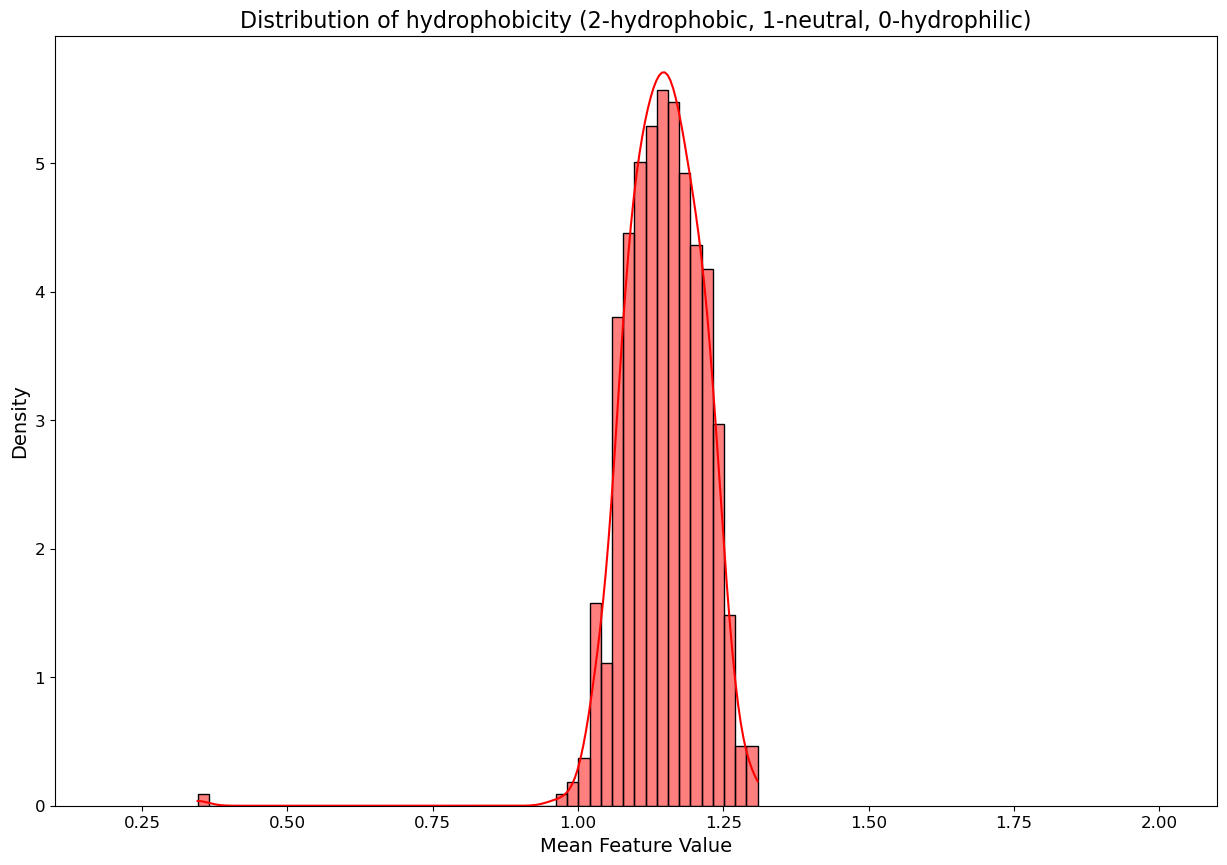

In [217]:
import seaborn as sns

# Create a labels dictionary for each feature
feature_names = [
    'hydrophobicity', 'volume', 'chem1', 'chem2', 'chem3', 'chem4', 'chem5', 'chem6', 'chem7', 'chem8',
    'charge', 'hydrogen', 'protonAffinity', 'globalChemSoft', 'sdcnChemSoft', 
    'globalPolarizability', 'bkbnPolarizability', 'disorder'
]

# Create a dictionary of colors for each feature
feature_colors = {
    'hydrophobicity': 'red',
    'volume': 'blue',
    'chem1': 'green',
    'chem2': 'purple',
    'chem3': 'orange',
    'chem4': 'brown',
    'chem5': 'pink',
    'chem6': 'grey',
    'chem7': 'black',
    'chem8': 'yellow',
    'charge': 'red',
    'hydrogen': 'blue',
    'protonAffinity': 'green',
    'globalChemSoft': 'purple',
    'sdcnChemSoft': 'orange',
    'globalPolarizability': 'brown',
    'bkbnPolarizability': 'pink',
    'disorder': 'grey'
}

ft_xlims = {'hydrophobicity': (0.1, 2.1),
    'volume': (-0.1, 5.1),
    'charge': (-0.20, 0.20),
    'hydrogen': (-0.1, 1.1),
    'protonAffinity': (0.1, 0.4),
    'globalChemSoft': (0.1, 0.40),
    'sdcnChemSoft': (0.2, 0.45),
    'globalPolarizability': (0.1, 0.5),
    'bkbnPolarizability': (0.2, 0.7),
    'disorder': (0.0, 0.4)}



# Compute the distribution of mean values for the first feature
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 0], bins=50, kde=True, stat='density', color=feature_colors[feature_names[0]])
plt.title('Distribution of hydrophobicity (2-hydrophobic, 1-neutral, 0-hydrophilic)', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 2.1)
plt.xlim(ft_xlims['hydrophobicity'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_hydrophobicity_mean_values.png")
plt.show()
plt.show()










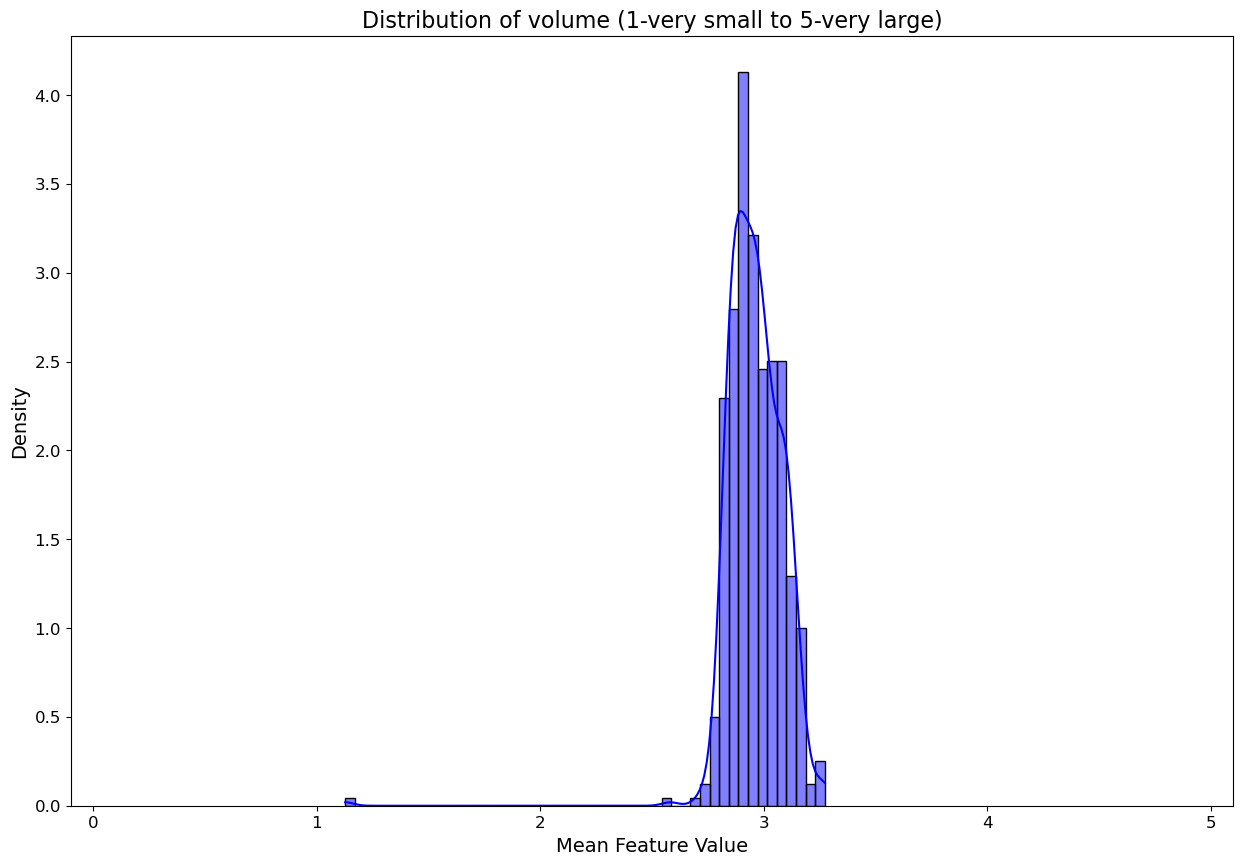

In [218]:
# Compute the distribution of mean values for the second feature
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 1], bins=50, kde=True, stat='density', color=feature_colors[feature_names[1]])
plt.title('Distribution of volume (1-very small to 5-very large)', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 5.1)
plt.xlim(ft_xlims['volume'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_volume_mean_values.png")
plt.show()

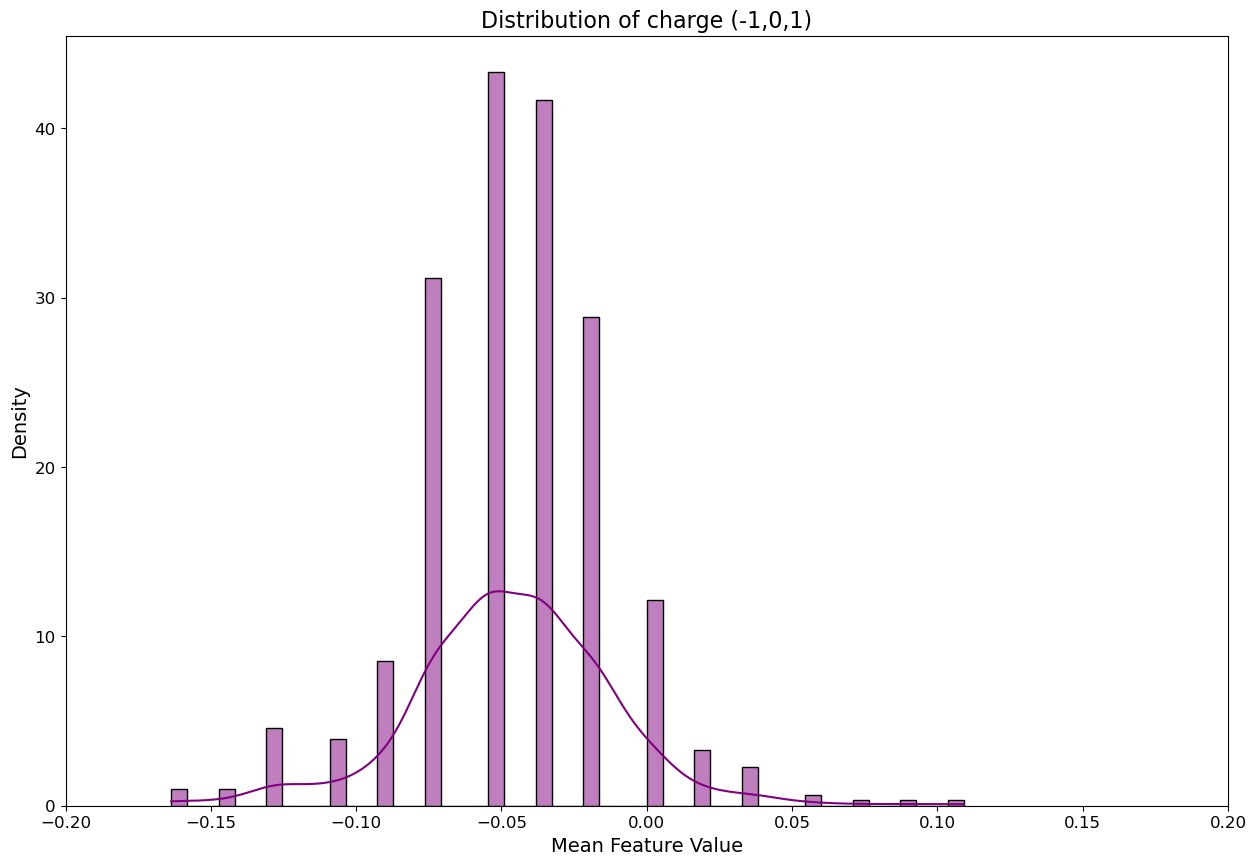

In [219]:
# Compute the distribution of mean values for the tenth feature (charge)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 10], bins=50, kde=True, stat='density', color=feature_colors[feature_names[3]])
plt.title('Distribution of charge (-1,0,1)', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-1.1, 1.1)
plt.xlim(ft_xlims['charge'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_charge_mean_values.png")
plt.show()

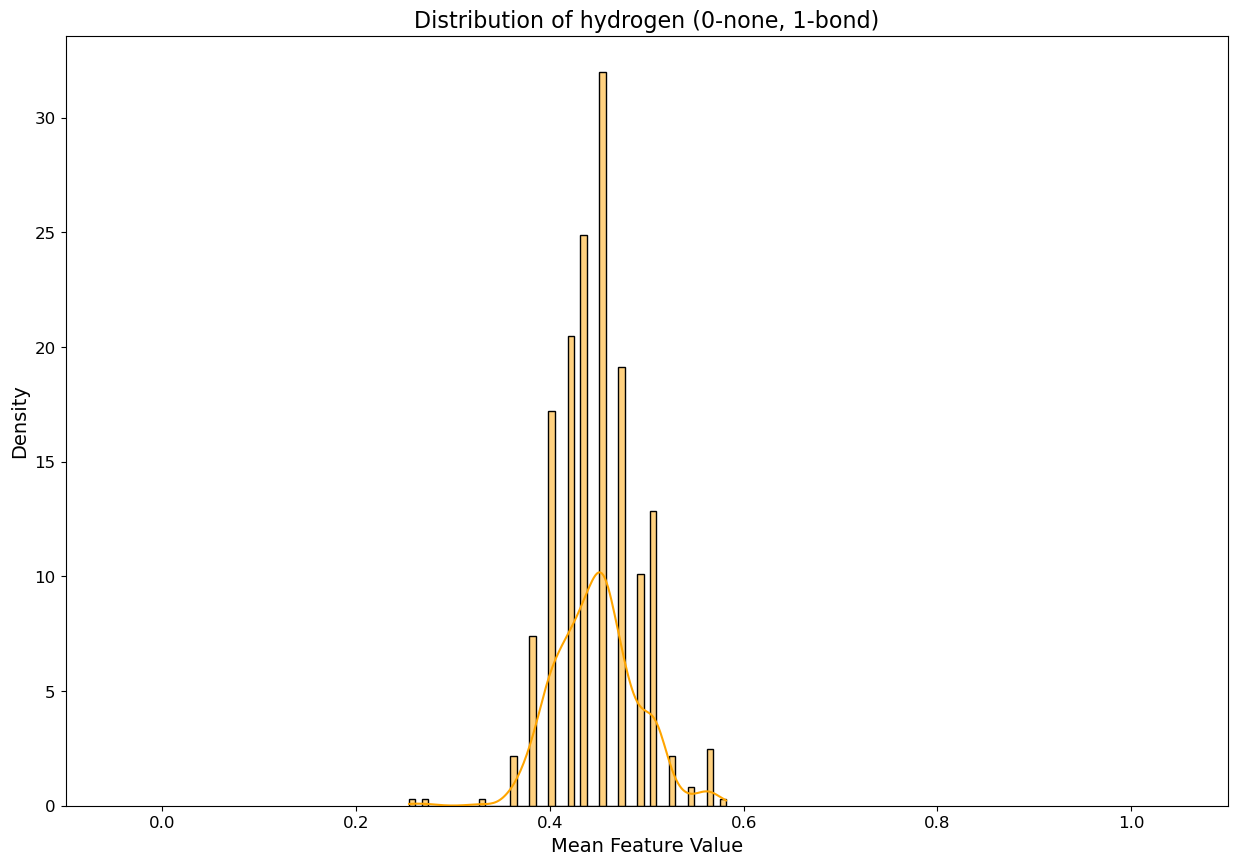

In [220]:
# Compute the distribution of mean values for the eleventh feature (hydrogen)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 11], bins=50, kde=True, stat='density', color=feature_colors[feature_names[4]])
plt.title('Distribution of hydrogen (0-none, 1-bond)', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
plt.xlim(ft_xlims['hydrogen'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_hydrogen_mean_values.png")
plt.show()

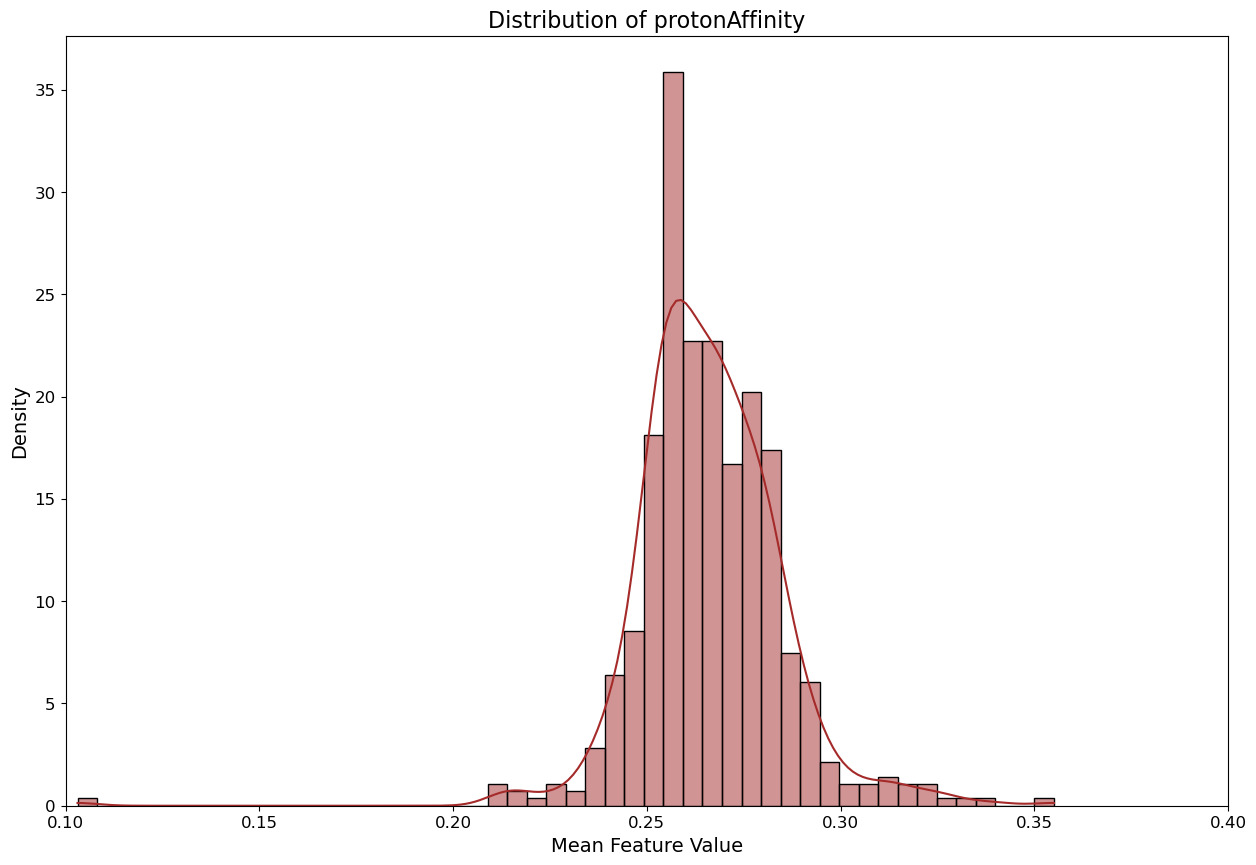

In [ ]:




# Compute the distribution of mean values for the twelfth feature (protonAffinity)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 12], bins=50, kde=True, stat='density', color=feature_colors[feature_names[5]])
plt.title('Distribution of protonAffinity', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
plt.xlim(ft_xlims['protonAffinity'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_protonAffinity_mean_values.png")
plt.show()

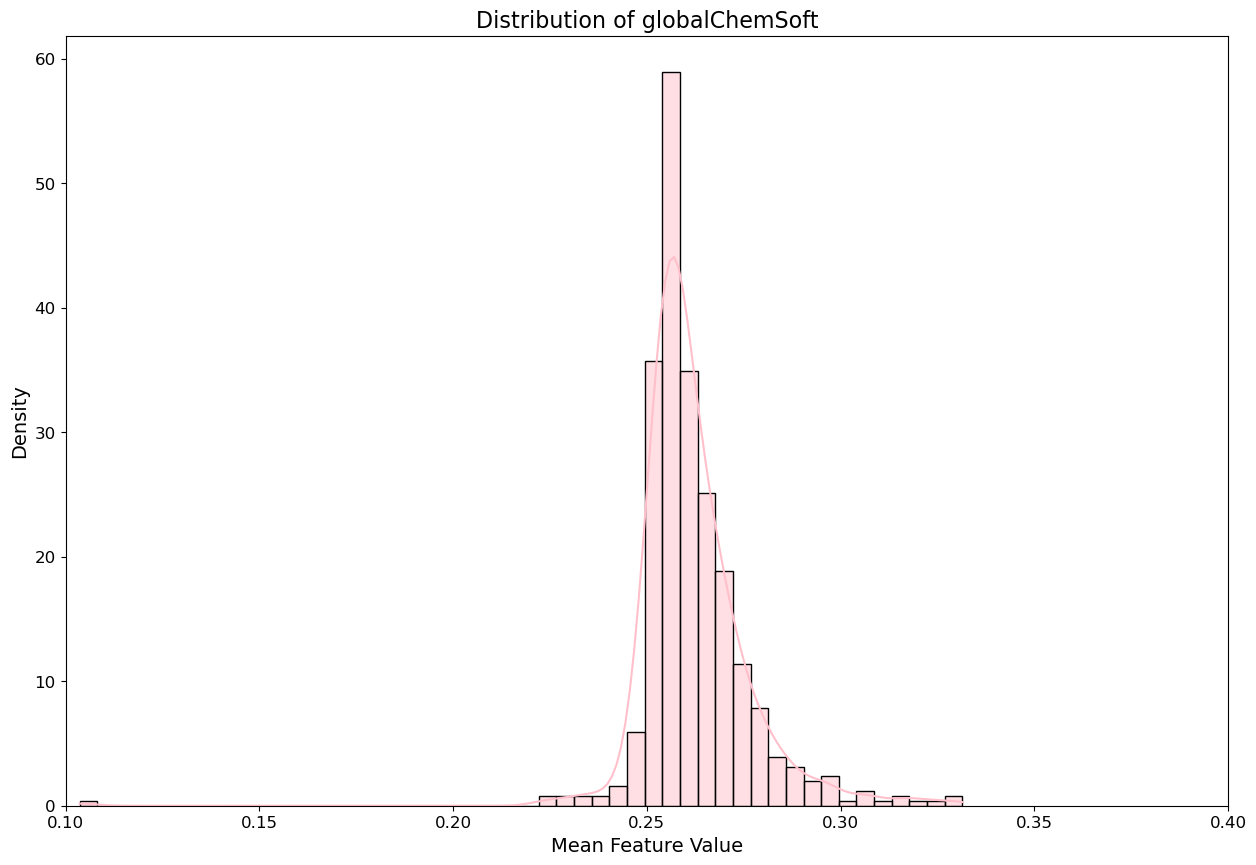

In [ ]:
# Compute the distribution of mean values for the thirteenth feature (globalChemSoft)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 13], bins=50, kde=True, stat='density', color=feature_colors[feature_names[6]])
plt.title('Distribution of globalChemSoft', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
#plt.ylim(0.0, 10)
plt.xlim(ft_xlims['globalChemSoft'])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_globalChemSoft_mean_values.png")
plt.show()


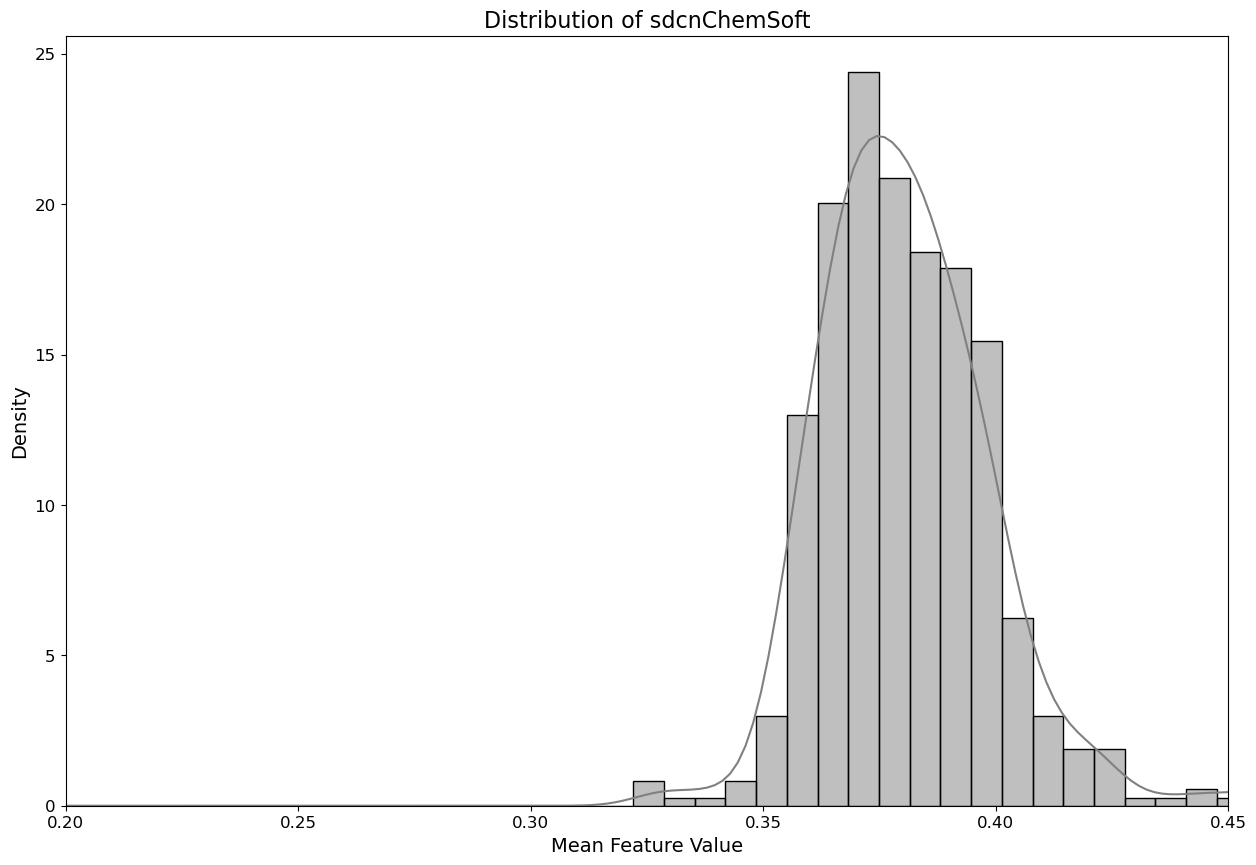

In [ ]:
# Compute the distribution of mean values for the fourteenth feature (sdcnChemSoft)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 14], bins=50, kde=True, stat='density', color=feature_colors[feature_names[7]])
plt.title('Distribution of sdcnChemSoft', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
#plt.ylim(0.0, 10)
plt.xlim(ft_xlims['sdcnChemSoft'])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_sdcnChemSoft_mean_values.png")
plt.show()


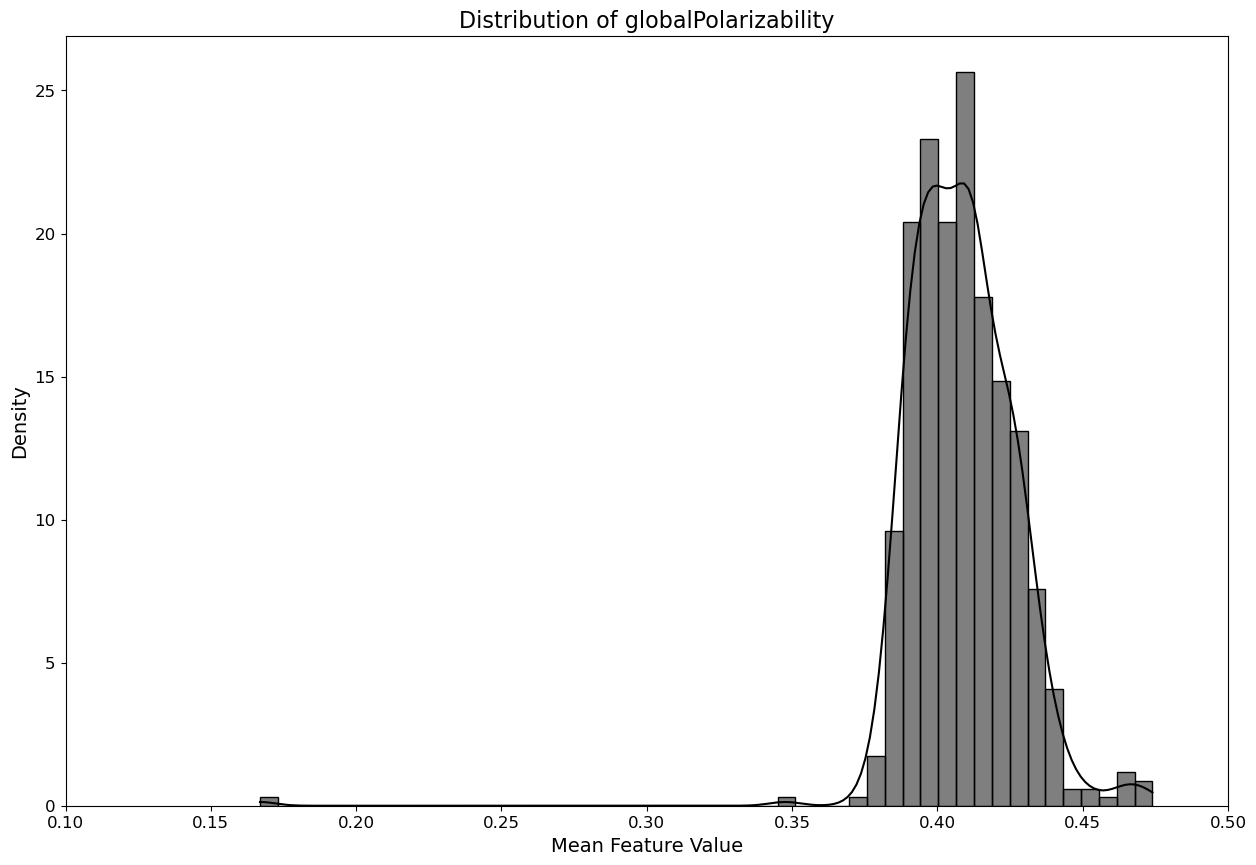

In [ ]:
# Compute the distribution of mean values for the fifteenth feature (globalPolarizability)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 15], bins=50, kde=True, stat='density', color=feature_colors[feature_names[8]])
plt.title('Distribution of globalPolarizability', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
plt.xlim(ft_xlims['globalPolarizability'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_globalPolarizability_mean_values.png")
plt.show()


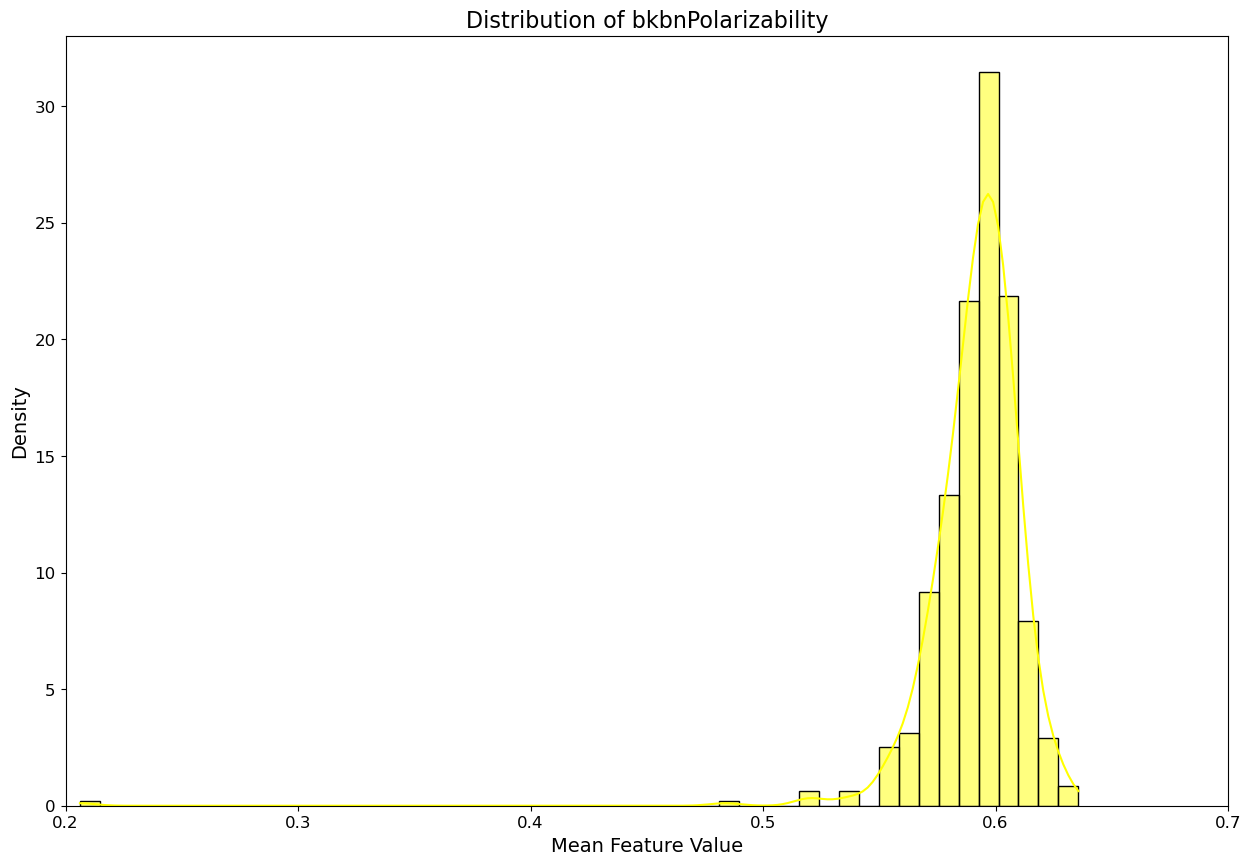

In [ ]:
# Compute the distribution of mean values for the sixteenth feature (bkbnPolarizability)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 16], bins=50, kde=True, stat='density', color=feature_colors[feature_names[9]])
plt.title('Distribution of bkbnPolarizability', fontsize=16)
plt.xlabel('Mean Feature Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
plt.xlim(ft_xlims['bkbnPolarizability'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_bkbnPolarizability_mean_values.png")
plt.show()


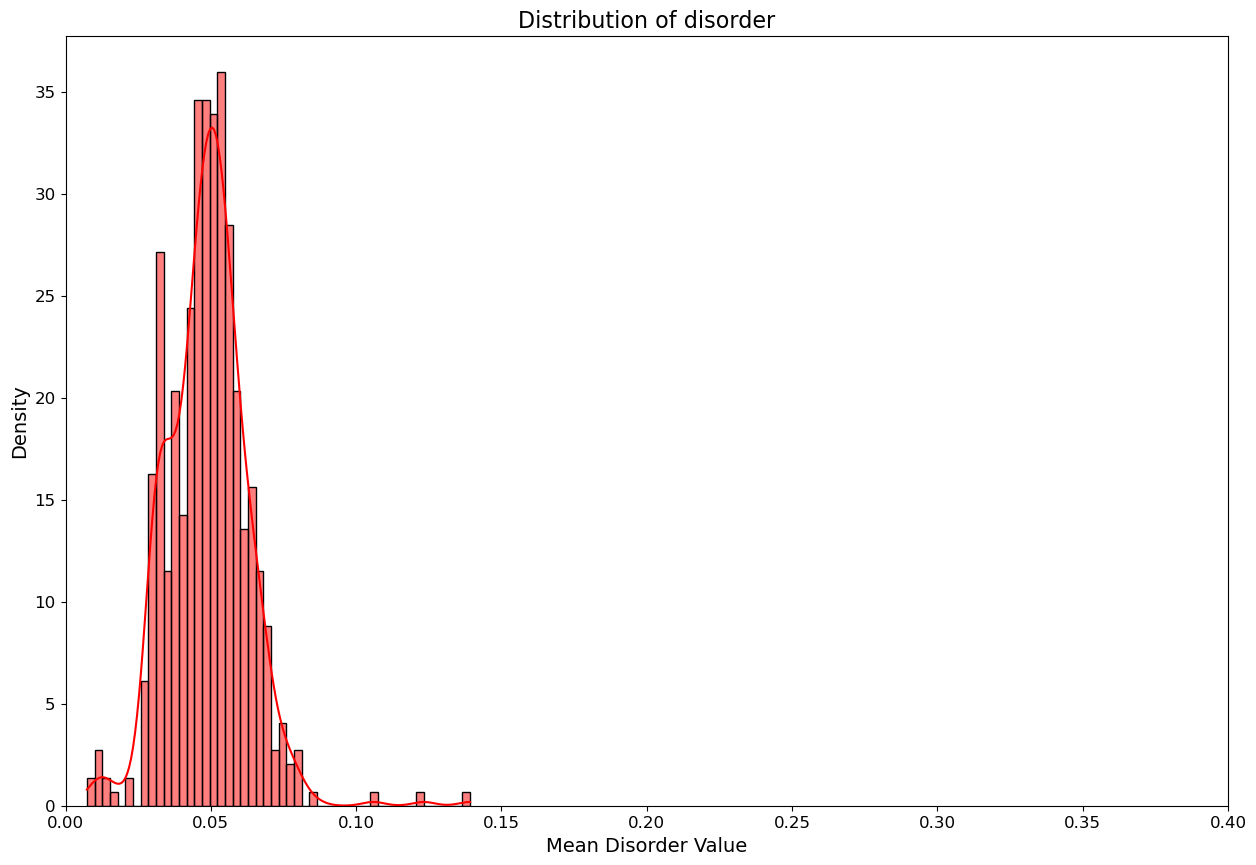

In [ ]:
# Compute the distribution of mean values for the seventeenth feature (disorder)
plt.figure(figsize=(15, 10))
sns.histplot(seq_tensors_mean[:, 17], bins=50, kde=True, stat='density', color=feature_colors[feature_names[10]])
plt.title('Distribution of disorder', fontsize=16)
plt.xlabel('Mean Disorder Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.xlim(-0.1, 1.1)
plt.xlim(ft_xlims['disorder'])
#plt.ylim(0.0, 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_disorder_mean_values.png")
plt.show()


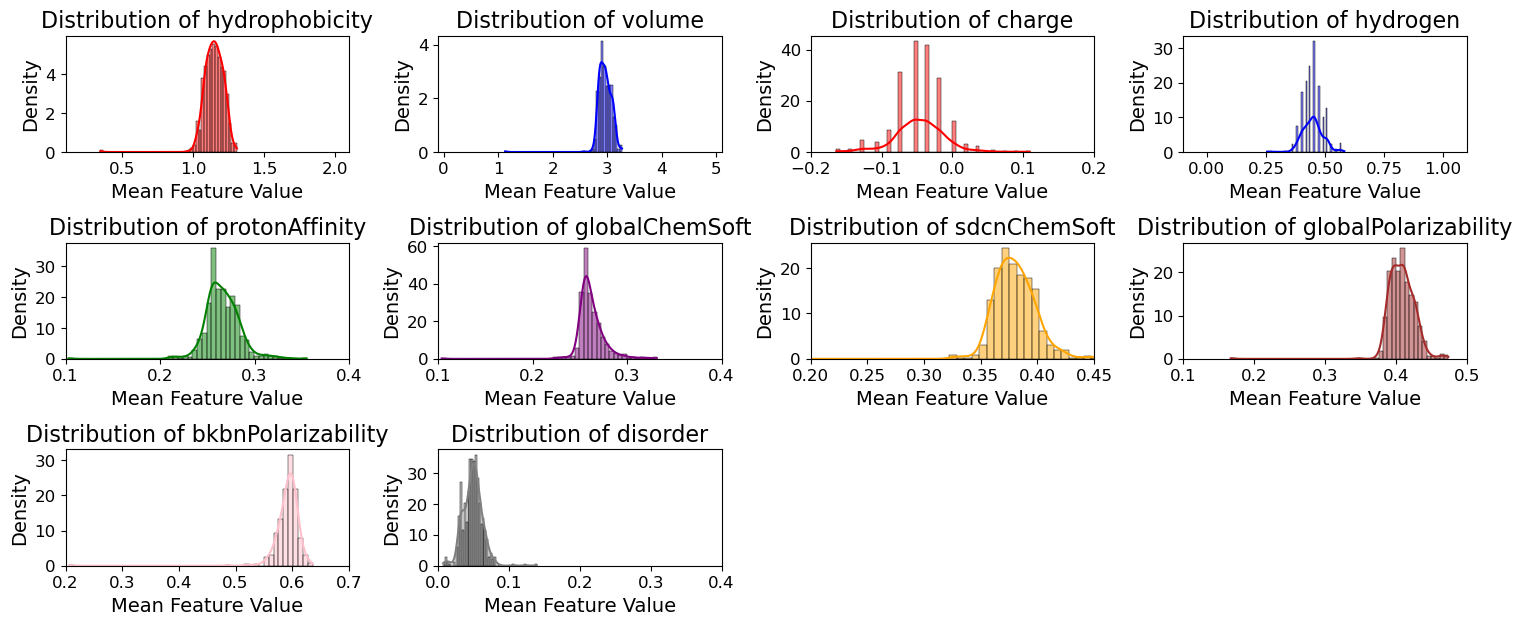

In [ ]:
plt.figure(figsize=(15, 10))
count = 0 

for i in range(seq_tensors_mean.shape[1]):
    if i in range(2,10):
        continue
    count += 1
   
    plt.subplot(5, 4, count)
    sns.histplot(seq_tensors_mean[:, i], bins=50, kde=True, stat='density', color=feature_colors[feature_names[i]])
    plt.title(f'Distribution of {feature_names[i]}', fontsize=16)
    plt.xlabel('Mean Feature Value', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.xticks(fontsize=12)
    plt.xlim(ft_xlims[feature_names[i]])
    plt.yticks(fontsize=12)
    # get the range of values in seq_tensors_mean[:, i]
    range_values = np.max(seq_tensors_mean[:, i]) - np.min(seq_tensors_mean[:, i])
    # Use only two decimal places
    range_values = round(range_values, 3)
    # get the standard deviation
    std = round(np.std(seq_tensors_mean[:, i]),3)
    # get the mean
    mean = round(np.mean(seq_tensors_mean[:, i]),3)
    # Get the mode
    from scipy.stats import mode
    mode_value, count2 = mode(seq_tensors_mean[:, i], axis=0, keepdims=True)
    # round the mode value
    mode_value = np.round(mode_value, 3)

    # Open a new file for this cluster and write the values
    with open(f"../data/subcluster/cluster_{cluster_number}_feature_{feature_names[i]}_distribution_descriptors.txt", 'a') as f:
        f.write(f"Feature: {feature_names[i]}\n")
        f.write(f"Range of values: {round(np.min(seq_tensors_mean[:, i]), 3)} - {round(np.max(seq_tensors_mean[:, i]), 3)}\n")
        f.write(f"Standard Deviation: {std}\n")
        f.write(f"Mean: {mean}\n")
        f.write(f"Mode: {mode_value[0]}, Count: {count2[0]}\n")
        f.write("\n")
plt.tight_layout()
plt.savefig(f"../data/subcluster/cluster_{cluster_number}_features_mean_values.png")
plt.show()



